# Pan Cell-Type Benchmark

This notebook generates the core thesis figures for one question:

**Does the mutation-based matching framework recover the correct broad cell type strongly enough to justify moving on to hepatocyte-state analysis?**

Outputs are written to:
- `figures/`
- `data/`


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300

RESULTS_PATH = Path('01_pan_celltype_benchmark_results.csv')
FIG_DIR = Path('figures')
SUM_DIR = Path('data')
FIG_DIR.mkdir(parents=True, exist_ok=True)
SUM_DIR.mkdir(parents=True, exist_ok=True)

print('Results:', RESULTS_PATH.resolve())
print('Figure directory:', FIG_DIR.resolve())
print('Summary directory:', SUM_DIR.resolve())


Results: /home/lem/projects/mut-epi-origin/outputs/thesis/01_pan_celltype_benchmark/01_pan_celltype_benchmark_results.csv
Figure directory: /home/lem/projects/mut-epi-origin/outputs/thesis/01_pan_celltype_benchmark/figures
Summary directory: /home/lem/projects/mut-epi-origin/outputs/thesis/01_pan_celltype_benchmark/data


In [2]:
df = pd.read_csv(RESULTS_PATH)
print('Rows:', len(df))
print('Columns:', len(df.columns))
print('Track strategies:', sorted(df['track_strategy'].dropna().unique().tolist()))

TRACK_ORDER = ['counts_raw', 'counts_gauss', 'exp_decay']
df['track_strategy'] = pd.Categorical(df['track_strategy'], categories=TRACK_ORDER, ordered=True)

SCORING_TO_IS_CORRECT = {
    'raw': 'is_correct_raw',
    'linear_resid': 'is_correct_linear_resid',
    'spearman_linear_resid': 'is_correct_spearman_linear_resid',
    'pearson_local_score': 'is_correct_pearson_local_score',
    'spearman_local_score': 'is_correct_spearman_local_score',
}
SCORING_TO_MARGIN = {
    'raw': 'best_minus_second_raw',
    'linear_resid': 'best_minus_second_linear_resid',
    'spearman_linear_resid': 'best_minus_second_spearman_linear_resid',
    'pearson_local_score': 'best_minus_second_pearson_local_score',
    'spearman_local_score': 'best_minus_second_spearman_local_score',
}
SCORING_TO_PRED = {
    'raw': 'pred_celltype_raw_canon',
    'linear_resid': 'pred_celltype_linear_resid_canon',
    'spearman_linear_resid': 'pred_celltype_spearman_linear_resid_canon',
    'pearson_local_score': 'pred_celltype_pearson_local_score_canon',
    'spearman_local_score': 'pred_celltype_spearman_local_score_canon',
}
SCORING_TO_SCORE_TEMPLATE = {
    'raw': 'pearson_r_raw_{ct}_mean_weighted',
    'linear_resid': 'pearson_r_linear_resid_{ct}_mean_weighted',
    'spearman_linear_resid': 'spearman_r_linear_resid_{ct}_mean_weighted',
    'pearson_local_score': 'pearson_local_score_global_{ct}_mean_weighted',
    'spearman_local_score': 'spearman_local_score_global_{ct}_mean_weighted',
}

# Strategy-aware bin field so all track strategies are analysed together.
df['bin_bp'] = np.select(
    [
        df['track_strategy'].eq('counts_raw'),
        df['track_strategy'].eq('counts_gauss'),
        df['track_strategy'].eq('exp_decay'),
    ],
    [
        df['counts_raw_bin'],
        df['counts_gauss_bin'],
        df['exp_decay_bin'],
    ],
    default=np.nan,
)

print('Strategy-aware bin sizes:', sorted(df['bin_bp'].dropna().unique().tolist()))

celltypes = []
prefix = 'pearson_r_raw_'
suffix = '_mean_weighted'
for col in df.columns:
    if col.startswith(prefix) and col.endswith(suffix):
        celltypes.append(col[len(prefix):-len(suffix)])
celltypes = sorted(celltypes)


def parse_true_labels(value: str) -> list[str]:
    if pd.isna(value):
        return []
    return [x.strip() for x in str(value).split(',') if x.strip()]


df['true_labels_list'] = df['correct_celltype_canon'].apply(parse_true_labels)
df['true_primary_label'] = df['true_labels_list'].apply(lambda xs: xs[0] if xs else np.nan)

print('Cell types:', celltypes)


Rows: 1471
Columns: 258
Track strategies: ['counts_gauss', 'counts_raw', 'exp_decay']
Strategy-aware bin sizes: [500000.0, 1000000.0]
Cell types: ['astro_hippo', 'astro_spinal', 'eso_epi', 'fibr', 'kera', 'mela', 'myel_prog', 'neuro_stem', 'nkc', 'smc']


In [3]:
LINEAGE_MAP = {
    'myel_prog': 'immune',
    'nkc': 'immune',
    'kera': 'epithelial',
    'eso_epi': 'epithelial',
    'smc': 'mesenchymal',
    'fibr': 'mesenchymal',
    'neuro_stem': 'neural',
    'astro_hippo': 'neural',
    'astro_spinal': 'neural',
    'mela': 'melanocytic',
}

df['true_lineage_set'] = df['true_labels_list'].apply(lambda xs: {LINEAGE_MAP.get(x) for x in xs if x in LINEAGE_MAP})
df['true_lineage_primary'] = df['true_primary_label'].map(LINEAGE_MAP)

for scoring, pred_col in SCORING_TO_PRED.items():
    df[f'pred_lineage__{scoring}'] = df[pred_col].map(LINEAGE_MAP)
    df[f'is_lineage_correct__{scoring}'] = [
        float(pred in truth_set) if isinstance(truth_set, set) and len(truth_set) > 0 else np.nan
        for pred, truth_set in zip(df[f'pred_lineage__{scoring}'], df['true_lineage_set'])
    ]


## 1) Overall Benchmark Performance Across Methods

Headline figure with:
- top-1 accuracy
- mean rank of true cell type
- top-3 rate of true cell type


/tmp/ipykernel_33686/3492936073.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = tmp.groupby(['track_strategy', 'bin_bp', 'scoring_system'], as_index=False).agg(
/tmp/ipykernel_33686/3492936073.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = tmp.groupby(['track_strategy', 'bin_bp', 'scoring_system'], as_index=False).agg(
/tmp/ipykernel_33686/3492936073.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warnin

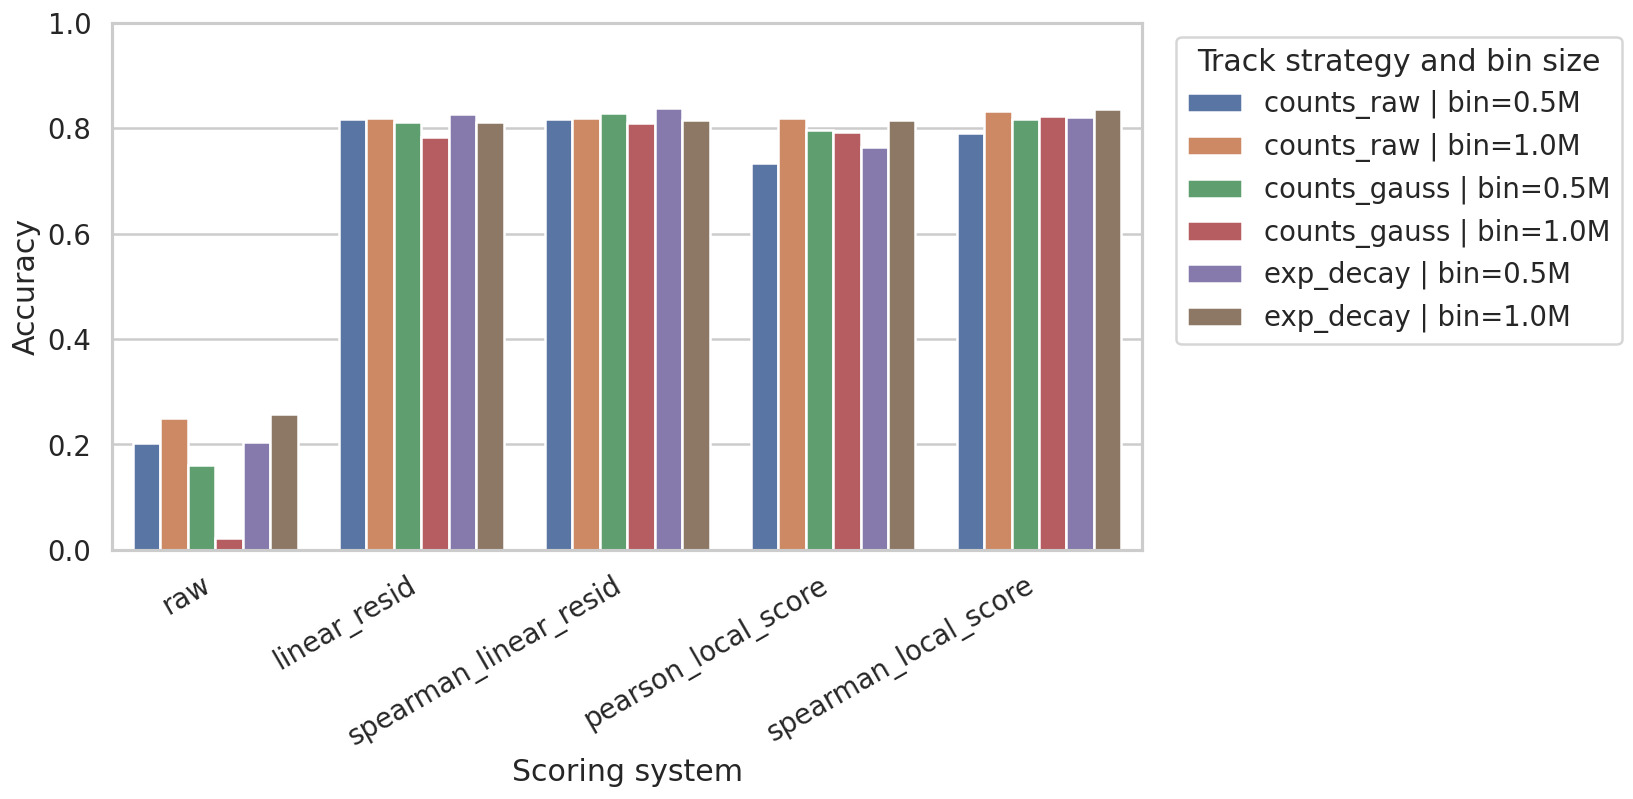

In [4]:
def compute_true_rank(frame: pd.DataFrame, scoring: str, cts: list[str]) -> pd.Series:
    cols = [SCORING_TO_SCORE_TEMPLATE[scoring].format(ct=ct) for ct in cts]
    sub = frame[['true_labels_list'] + cols].copy()
    vals = sub[cols].to_numpy(dtype=float)
    order = np.argsort(vals, axis=1)
    rank_pos = np.empty_like(order)
    rank_pos[np.arange(order.shape[0])[:, None], order] = np.arange(order.shape[1])[None, :]
    ct_to_idx = {ct: i for i, ct in enumerate(cts)}

    ranks = np.full(len(sub), np.nan)
    for i, labels in enumerate(sub['true_labels_list']):
        idxs = [ct_to_idx[x] for x in labels if x in ct_to_idx]
        if len(idxs) == 0:
            continue
        ranks[i] = float(min(int(rank_pos[i, j]) + 1 for j in idxs))
    return pd.Series(ranks, index=frame.index)

rows = []
for scoring, is_col in SCORING_TO_IS_CORRECT.items():
    tmp = df[['track_strategy', 'bin_bp', is_col]].copy()
    tmp['scoring_system'] = scoring
    tmp['top1_accuracy'] = tmp[is_col].astype(float)
    grp = tmp.groupby(['track_strategy', 'bin_bp', 'scoring_system'], as_index=False).agg(
        top1_accuracy=('top1_accuracy', 'mean'),
    )
    rows.append(grp)

perf = pd.concat(rows, ignore_index=True)
perf['config_label'] = perf['track_strategy'].astype(str) + ' | bin=' + (perf['bin_bp'] / 1_000_000).round(1).astype(str) + 'M'
perf.to_csv(SUM_DIR / '01_overall_performance_metrics.csv', index=False)

plt.figure(figsize=(14, 7))
sns.barplot(
    data=perf,
    x='scoring_system',
    y='top1_accuracy',
    hue='config_label',
)
plt.xlabel('Scoring system')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=30, ha='right')
ax_panel = plt.gca()
plt.legend(title='Track strategy and bin size', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(FIG_DIR / '01_overall_benchmark_performance.png', bbox_inches='tight')
plt.show()


## 2) Performance by Cancer Type (Best Setup)

Top-1 assignment accuracy by cancer type for the single best overall setup.


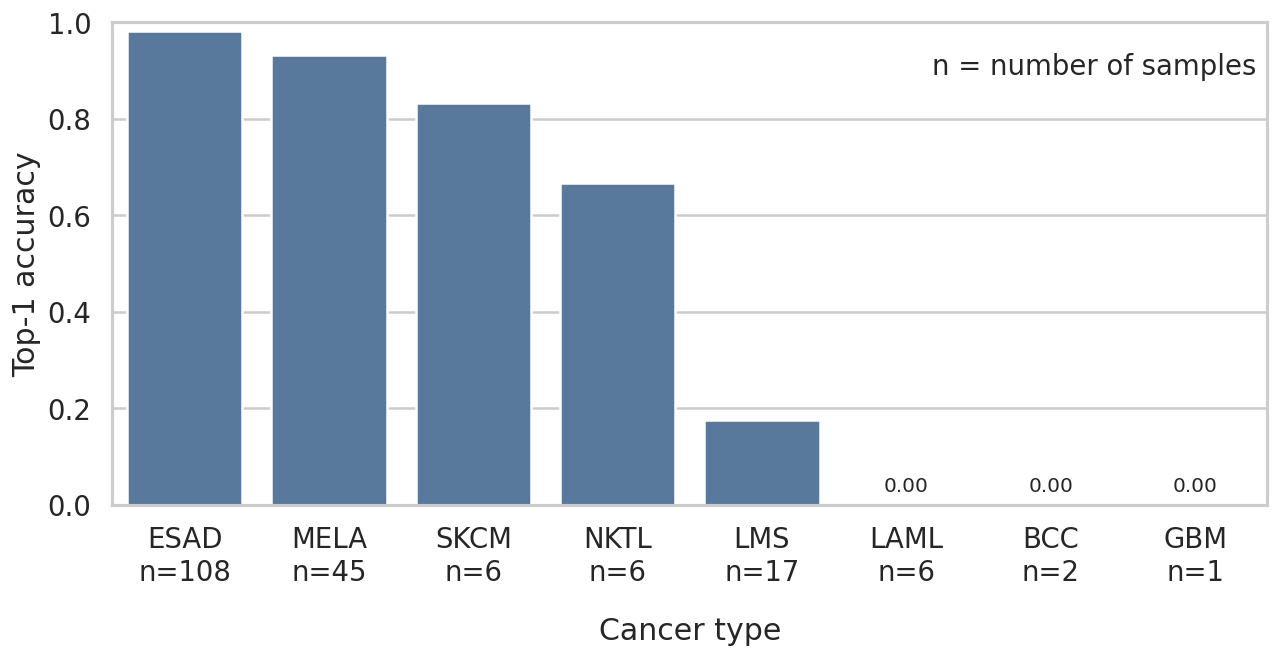

In [5]:
best_row = perf.sort_values('top1_accuracy', ascending=False).iloc[0]
best_scoring = best_row['scoring_system']
best_track = best_row['track_strategy']
best_bin = best_row['bin_bp']
best_is_col = SCORING_TO_IS_CORRECT[best_scoring]
best_pred_col = SCORING_TO_PRED[best_scoring]

sub = df[(df['track_strategy'] == best_track) & (df['bin_bp'] == best_bin)].copy()
sub = sub[['selected_tumour_types', best_is_col]].dropna()
sub = sub.rename(columns={best_is_col: 'is_correct'})

# Keep first tumour-type token if multiple are present.
sub['cancer_type'] = sub['selected_tumour_types'].astype(str).str.split(',').str[0].str.strip()

perf_by_cancer = (
    sub.groupby('cancer_type', as_index=False)
    .agg(
        top1_accuracy=('is_correct', 'mean'),
        n_samples=('is_correct', 'size'),
        n_correct=('is_correct', 'sum'),
    )
    .sort_values(['top1_accuracy', 'n_samples'], ascending=[False, False])
    .reset_index(drop=True)
)

perf_by_cancer['x_label'] = perf_by_cancer['cancer_type'] + '\n' + 'n=' + perf_by_cancer['n_samples'].astype(int).astype(str)
perf_by_cancer.to_csv(SUM_DIR / '02_top1_accuracy_by_cancer_type_best_setup.csv', index=False)

plt.figure(figsize=(11, 6))
ax = sns.barplot(data=perf_by_cancer, x='x_label', y='top1_accuracy', color='#4c78a8', errorbar=None)

# Make zero-accuracy groups explicit.
for patch, yi in zip(ax.patches, perf_by_cancer['top1_accuracy']):
    if yi == 0:
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            0.02,
            '0.00',
            ha='center',
            va='bottom',
            fontsize=12,
        )

plt.ylim(0, 1)
plt.xlabel('Cancer type', labelpad=18)
plt.ylabel('Top-1 accuracy')
plt.xticks(rotation=0, ha='center')

# Legend note at bottom-left.
from matplotlib.patches import Patch
note_handle = Patch(facecolor='none', edgecolor='none', label='n = number of samples')
plt.legend(handles=[note_handle], loc='upper right', bbox_to_anchor=(1.0, 0.96), frameon=False, handlelength=0, handletextpad=0, borderaxespad=0.0)

plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.savefig(FIG_DIR / '02_performance_by_cancer_type_best_setup.png')
plt.show()


## 3) Score-Gap Confidence Plot

Compares best-vs-second score gaps for correct vs incorrect predictions.


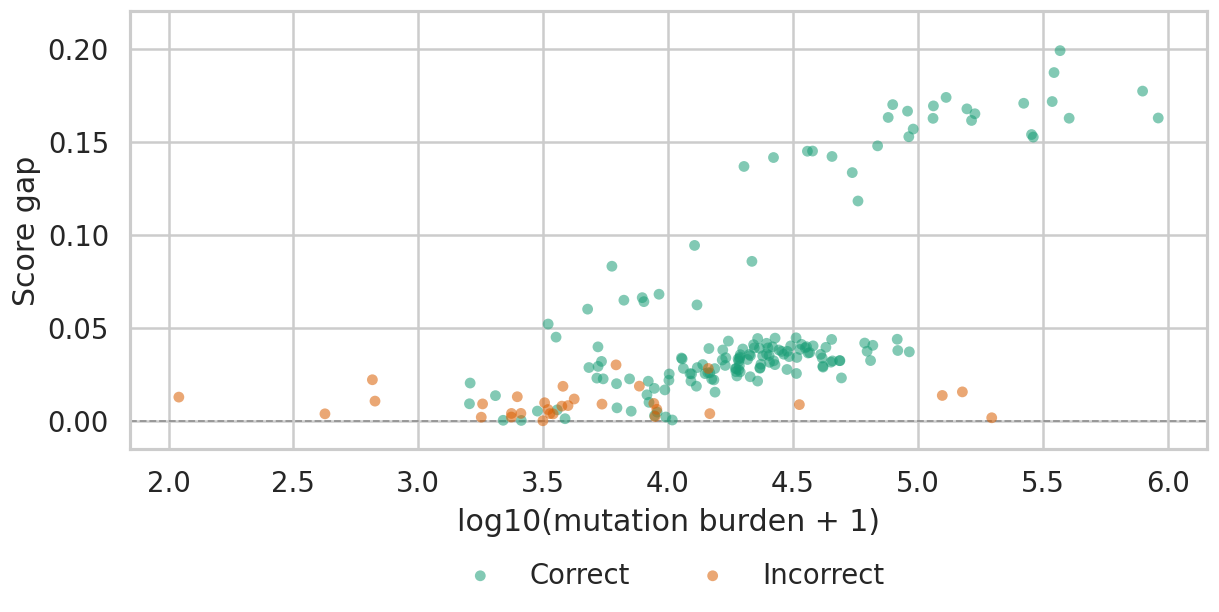

In [6]:
# Figure 3: sample-level confidence for the selected benchmark setup.
selected_scoring = best_scoring
selected_track = best_track
selected_bin_bp = best_bin
selected_margin_col = SCORING_TO_MARGIN[selected_scoring]
selected_is_col = SCORING_TO_IS_CORRECT[selected_scoring]

plot4 = df[(df['track_strategy'] == selected_track) & (df['bin_bp'] == selected_bin_bp)].copy()
plot4 = plot4[['sample_id', 'mutations_post_downsample', selected_margin_col, selected_is_col]].dropna()
plot4 = plot4.rename(columns={
    selected_margin_col: 'score_gap',
    selected_is_col: 'top1_correct',
})

plot4 = plot4[plot4['mutations_post_downsample'] >= 0].copy()
plot4['log10_mutation_burden'] = np.log10(plot4['mutations_post_downsample'] + 1.0)
plot4['assignment'] = np.where(plot4['top1_correct'].astype(float) == 1.0, 'Correct', 'Incorrect')
plot4['selected_scoring'] = selected_scoring
plot4['selected_track'] = selected_track
plot4['selected_bin_bp'] = selected_bin_bp

plot4.to_csv(SUM_DIR / '04_score_gap_vs_mutation_burden_selected_setup.csv', index=False)

plt.figure(figsize=(10.5, 6.0))
ax = plt.gca()

palette = {'Correct': '#1b9e77', 'Incorrect': '#d95f02'}
for label in ['Correct', 'Incorrect']:
    sub = plot4[plot4['assignment'] == label]
    ax.scatter(
        sub['log10_mutation_burden'],
        sub['score_gap'],
        s=42,
        alpha=0.55,
        c=palette[label],
        edgecolors='none',
        label=label,
        zorder=2,
    )

ax.axhline(0.0, linestyle='--', linewidth=1.1, color='#7a7a7a', alpha=0.7, zorder=1)
ax.set_xlabel('log10(mutation burden + 1)', labelpad=6)
ax.set_ylabel('Score gap')
ax.set_ylim(-0.015, 0.22)

# Legend outside the plot area.
ax.legend(
    title=None,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.20),
    ncol=2,
    frameon=False,
)

plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.savefig(FIG_DIR / '03_score_gap_vs_mutation_burden_best_setup.png', bbox_inches='tight', pad_inches=0.04)
plt.show()


## Figure Manifest

In [7]:
figs = sorted([p.name for p in FIG_DIR.glob('*.png')])
for f in figs:
    print(f)
print('\nTotal figures:', len(figs))


01_overall_benchmark_performance.png
02_performance_by_cancer_type_best_setup.png
03_score_gap_vs_mutation_burden_best_setup.png

Total figures: 3
